In [40]:
import numpy as np
import pandas as pd

In [41]:
df_buss=pd.read_csv(r"D:\dataset\New folder (2)\Indian News Article Classification\business_data.csv")
df_buss.head(2)

,headlines,description,content,url,category
0,Nirmala Sitharaman to equal Morarji Desai’s re...,With the presentation of the interim budget on...,"Sitharaman, the first full-time woman finance ...",https://indianexpress.com/article/business/bud...,business
1,"‘Will densify network, want to be at least no....","'In terms of market share, we aim to double it...",The merger of Tata group’s budget airlines Air...,https://indianexpress.com/article/business/avi...,business


In [42]:
df_edu=pd.read_csv(r"D:\dataset\New folder (2)\Indian News Article Classification\education_data.csv")
df_edu.head(2)

,headlines,description,content,url,category
0,CUET PG 2024: Register with NTA to enable admi...,CUET PG 2024: UGC said that the list of partic...,The Common University Entrance Test Postgradua...,https://indianexpress.com/article/education/cu...,education
1,Oxford ends ties with TCS iON over technical g...,"On April 10, 2023 TCS had announced that it ha...",Less than a year after the Oxford University s...,https://indianexpress.com/article/education/ox...,education


In [43]:
df_ent=pd.read_csv(r"D:\dataset\New folder (2)\Indian News Article Classification\entertainment_data.csv")
df_ent.head(2)

,headlines,description,content,url,category
0,Bhumi Pednekar plays an investigative journali...,Bhumi Pednekar plays an investigative journali...,Actor Bhumi Pednekar is all set to take over t...,https://indianexpress.com/article/entertainmen...,entertainment
1,Karan Johar channels his inner Rajinikanth in ...,Karan Johar and Kiara Advani featured in a new...,Karan Johar reunited with his Lust Stories sta...,https://indianexpress.com/article/entertainmen...,entertainment


In [44]:
df_sp=pd.read_csv(r"D:\dataset\New folder (2)\Indian News Article Classification\sports_data.csv")
df_sp.head(2)

,headlines,description,content,url,category
0,Jannik Sinner’s strong and improved baseline g...,Baseline strategy has been central to Jannik S...,"In a resolute, nerveless, three-hour-long disp...",https://indianexpress.com/article/sports/tenni...,sports
1,Allan Border opens up about Parkinson’s diseas...,Former Australia captain says the disease has ...,Legendary Australia cricketer Allan Border has...,https://indianexpress.com/article/sports/crick...,sports


In [45]:
df_tech=pd.read_csv(r"D:\dataset\New folder (2)\Indian News Article Classification\technology_data.csv")
df_tech.head(2)

,headlines,description,content,url,category
0,Unlocking the science of E Ink displays: Why w...,That e-reader screen isn't magic - it's E Ink!...,"With their crisp, paper-like screens, e-reader...",https://indianexpress.com/article/technology/t...,technology
1,Reddit is free education: 9 subreddits that ca...,These subreddits bring the best of the Interne...,"Education is the key to success, it not only l...",https://indianexpress.com/article/technology/f...,technology


In [46]:
df = pd.concat([df_buss, df_edu, df_ent, df_sp, df_tech], ignore_index=True)
df = df[['content', 'category']]
df.dropna(inplace=True)
df.head()

,content,category
0,"Sitharaman, the first full-time woman finance ...",business
1,The merger of Tata group’s budget airlines Air...,business
2,The Air India group plans to induct one aircra...,business
3,Indian exporters have asked the central govern...,business
4,The Air India group plans to induct one aircra...,business


In [47]:
def relabel_category(row):
    text = row['content'].lower()
    
    if row['category'] == 'business':
        if any(word in text for word in ['election', 'minister', 'parliament', 'government']):
            return 'politics'
        elif any(word in text for word in ['army', 'navy', 'air force', 'defence', 'military']):
            return 'defence'
        else:
            return 'business'
    return row['category']

In [48]:
df['category'] = df.apply(relabel_category, axis=1)

In [49]:
df['category'].value_counts()

category
sports           2000
entertainment    2000
education        2000
technology       2000
business         1400
politics          592
defence             8
Name: count, dtype: int64

In [50]:
X = df['content']
y = df['category']

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english',max_df=0.9,min_df=5)

In [53]:
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

In [54]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [72]:
def plot_top_words(classifier, vectorizer, category, top_n=20):
    # Get index of the category
    class_index = list(classifier.classes_).index(category)

    # Get feature names (words)
    feature_names = np.array(vectorizer.get_feature_names_out())

    # Get log probabilities for the category
    log_probs = classifier.feature_log_prob_[class_index]

    # Convert log probs to actual probabilities
    probs = np.exp(log_probs)

    # Get top N words
    top_indices = np.argsort(probs)[-top_n:]
    top_words = feature_names[top_indices]
    top_probs = probs[top_indices]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(top_words, top_probs, color="#1f77b4")
    plt.xlabel("Probability")
    plt.title(f"Top {top_n} Words for Category: {category.capitalize()}")
    plt.tight_layout()
    plt.show()

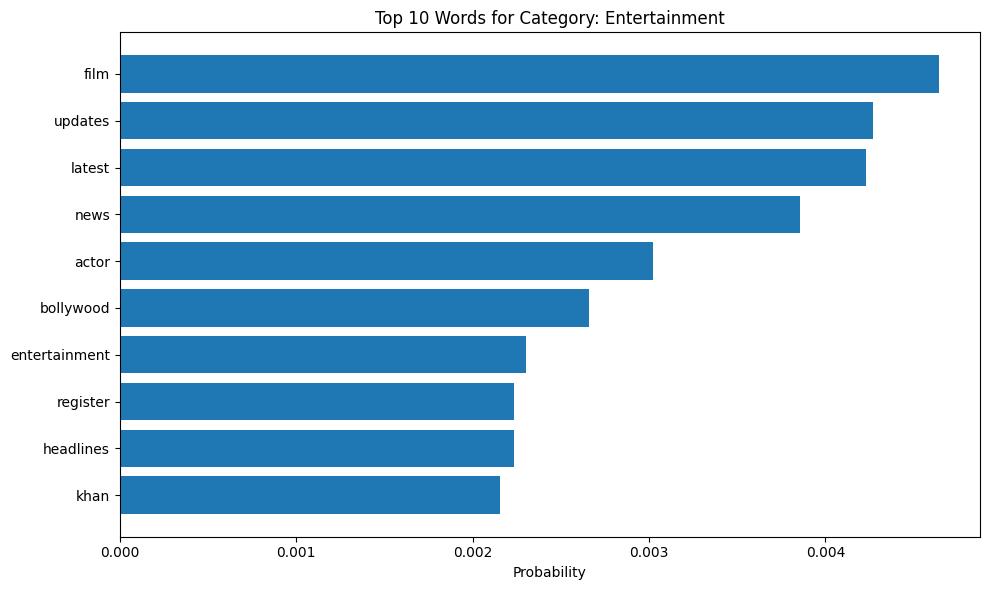

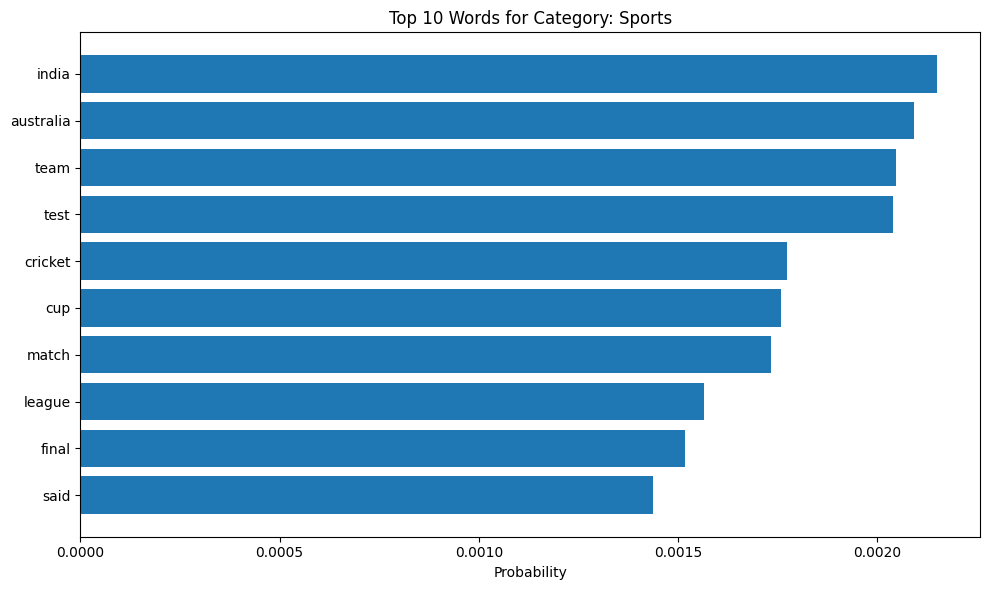

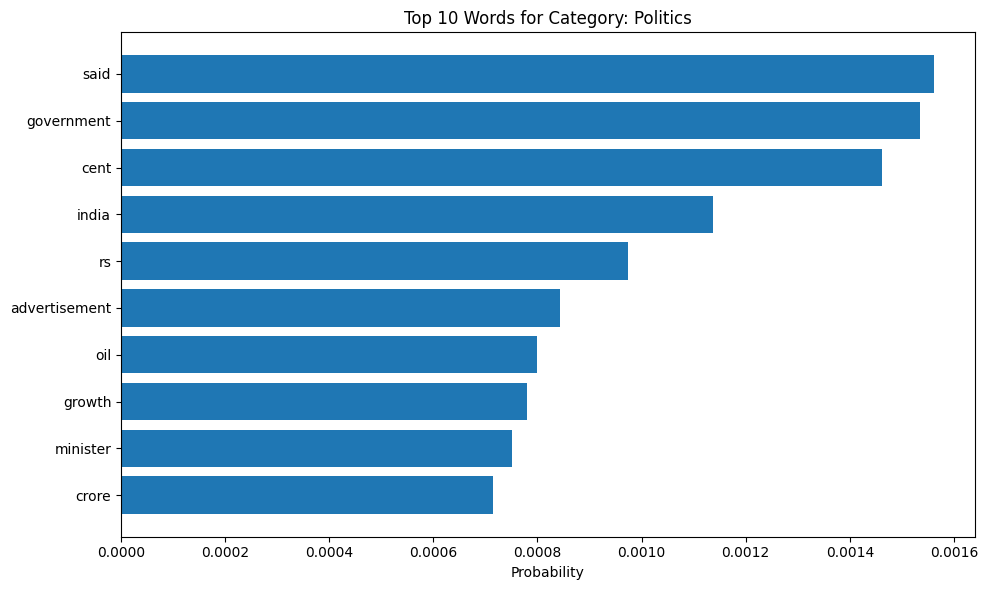

In [77]:
plot_top_words(model, tfidf, category='entertainment', top_n=10)
plot_top_words(model, tfidf, category='sports', top_n=10)
plot_top_words(model, tfidf, category='politics', top_n=10)

In [55]:
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix

In [56]:
y_pred = model.predict(X_test_vec)
y_pred

array(['business', 'education', 'entertainment', ..., 'sports',
       'business', 'education'], shape=(2000,), dtype='<U13')

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred,zero_division=0))
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9195
Classification Report:
                precision    recall  f1-score   support

     business       0.74      0.89      0.81       280
      defence       0.00      0.00      0.00         2
    education       0.97      0.99      0.98       400
entertainment       0.99      1.00      0.99       400
     politics       0.86      0.10      0.18       118
       sports       0.99      0.99      0.99       400
   technology       0.89      0.97      0.93       400

     accuracy                           0.92      2000
    macro avg       0.78      0.71      0.70      2000
 weighted avg       0.92      0.92      0.90      2000

Confusion Matrix:
 [[250   0   2   1   1   1  25]
 [  2   0   0   0   0   0   0]
 [  0   0 395   1   0   1   3]
 [  0   0   0 400   0   0   0]
 [ 83   0   7   0  12   0  16]
 [  0   0   0   2   0 395   3]
 [  5   0   2   1   1   4 387]]


In [59]:
import matplotlib.pyplot as plt
import seaborn as sbn

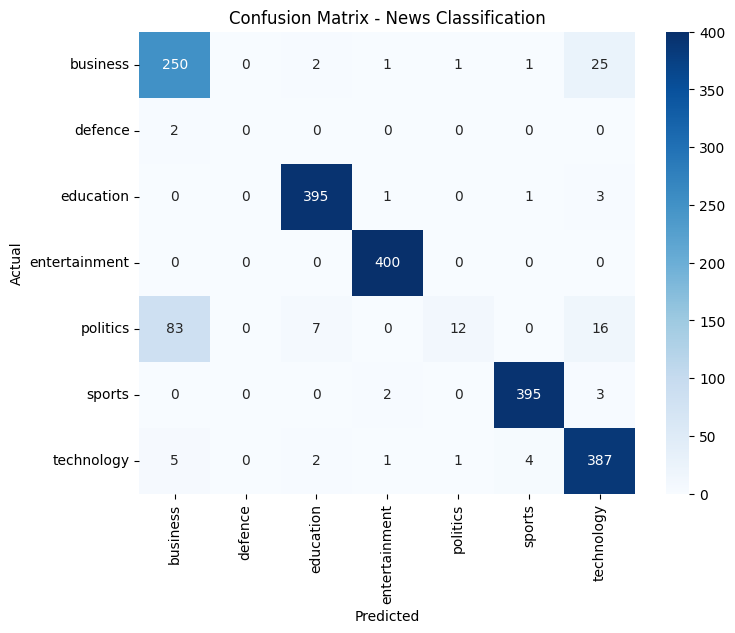

In [60]:
plt.figure(figsize=(8,6))
sbn.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=model.classes_,yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - News Classification")
plt.show()

In [61]:
def predict_news_category(article_text):
    vector = tfidf.transform([article_text])
    prediction = model.predict(vector)[0]
    return prediction

In [62]:
user_article = input("Paste a news article here:\n\n")
predicted_category = predict_news_category(user_article)
print("\nPredicted News Category:", predicted_category.upper())

Paste a news article here:

 IND vs NZ: Sanju Samson told not to bat like Abhishek Sharma after hattrick of failures



Predicted News Category: SPORTS


In [81]:
user_article = input("Paste a news article here:\n\n")
predicted_category = predict_news_category(user_article)
print("\nPredicted News Category:", predicted_category.upper())

Paste a news article here:

 Sitharaman, the first full time woman finance minister of the country has presented 5 full budget



Predicted News Category: POLITICS


In [82]:
user_article = input("Paste a news article here:\n\n")
predicted_category = predict_news_category(user_article)
print("\nPredicted News Category:", predicted_category.upper())

Paste a news article here:

 Esha Deol shares Border2 reviews



Predicted News Category: ENTERTAINMENT
